In [1]:
from ultralytics import YOLO

model_path = "../Models/yolov8n.pt"
model = YOLO(model_path)

General Plan:
1) Undistort the same as Blindspot detection
2) Create a trapezoid the contains the whole lane behind the car
3) if a car is detected in the zone -> the zone refits so that it does not touch the car 
4) Based on the change on length of the trapezoid is the change in distance between both cars
5) if the car is in collision with the main within x seconds -> warning
6) after a Z seconds the trapezoid will revert its shape to take the whole lane if the car has not touched the new zone (meaning that the distance between the cars have increased) 
----
To do the resizing can use the binary search alg if its in you go half again if its out you go half up until you get very close 
To do change the scaling variables to give a better deeper view of the road 
Detect lane markings and check for curves so that the trapezoid is better 

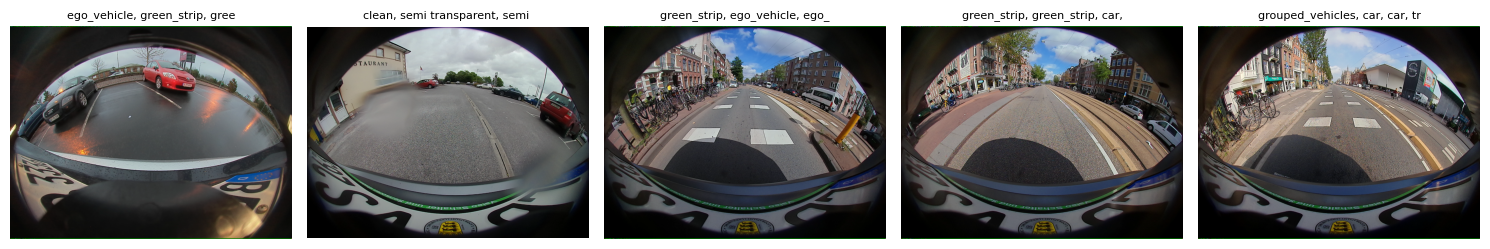

In [2]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np 
from pathlib import Path


data_dir = Path.cwd().parent / "Data"

train_img_path = data_dir / "train" / "img"
train_ann_path = data_dir / "train" / "ann"


RV_images = [p for p in os.listdir(train_img_path) if "_RV" in os.path.splitext(os.path.basename(p))[0]]
test_images = random.sample(RV_images, 5)

with open("test_images.json","w") as f:
    json.dump(test_images, f)

plt.figure(figsize=(15, 10))
for i, img_name in enumerate(test_images):
    img_path = os.path.join(train_img_path, img_name)
    image = Image.open(img_path)

    # Match JSON annotation file
    ann_name = img_name + ".json"
    ann_path = os.path.join(train_ann_path, ann_name)

    label_text = "No label file"
    if os.path.exists(ann_path):
        with open(ann_path, 'r') as f:
            ann_data = json.load(f)
            if 'objects' in ann_data:
                # Get the class titles
                labels = [obj.get('classTitle', 'unknown') for obj in ann_data['objects']]
                label_text = ', '.join(labels) if labels else "No objects found"

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(label_text[:30], fontsize=8)
    plt.axis('off')
    

plt.tight_layout()
plt.show()


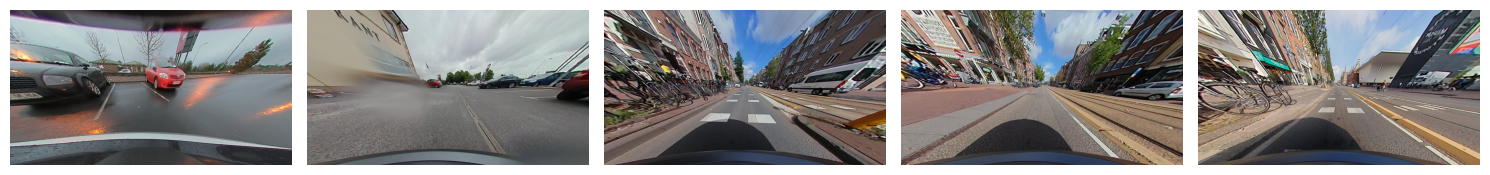

In [3]:

# Original intrinsics   
K = np.array([
    [350.0, 0.0, 640.0],  # fx, 0, cx
    [0.0, 350.0, 483.0],  # 0, fy, cy
    [0.0, 0.0, 1.0]
])
D = np.array([-0.01, 0.01, -0.001, 0.0005])  # fisheye distortion coefficients

def init_undistort_maps(K, D, image_size, balance, scale):
    w, h = image_size

    # New camera matrix with adjustable scaling
    new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        K, D, (w, h), np.eye(3), balance=balance, new_size=(w, h), fov_scale=scale
    )

    map1, map2 = cv2.fisheye.initUndistortRectifyMap(
        K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2
    )
    return map1, map2, new_K

# Changing the scale parameters to get a wider view instead of a deeper view 
map1, map2, new_K = init_undistort_maps(K, D, (1280, 966), balance=0.8, scale=0.22)

def undistort_fisheye(image, map1, map2):
    return cv2.remap(image, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

# Load your image list
with open("test_images.json", "r") as f:
    test_images = json.load(f)

# Output folder
output_folder =  Path.cwd().parent / "Notebooks" / "RV_undistorted_results"
output_folder.mkdir(exist_ok=True)

# Clear output folder
for p in output_folder.iterdir():
    if p.is_file():
        p.unlink()
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(15, 10))

for i, img_name in enumerate(test_images):
    img = cv2.imread(os.path.join(train_img_path, img_name))
    und = undistort_fisheye(img, map1, map2)

    h = und.shape[0]
    # crop the bottom 27% to remove the camera body (because it would sometimes detect it as a car)
    und = und[: int(h * 0.73) ]   

    cv2.imwrite(os.path.join(output_folder, img_name), und)
    plt.subplot(1, len(test_images), i+1)
    plt.imshow(cv2.cvtColor(und, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()



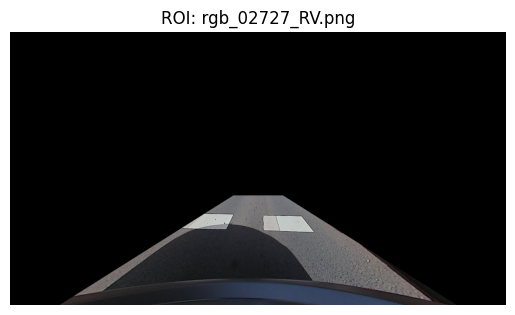

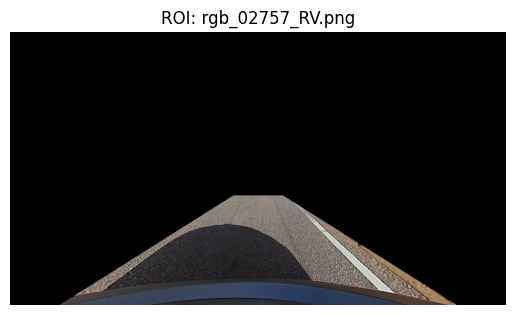

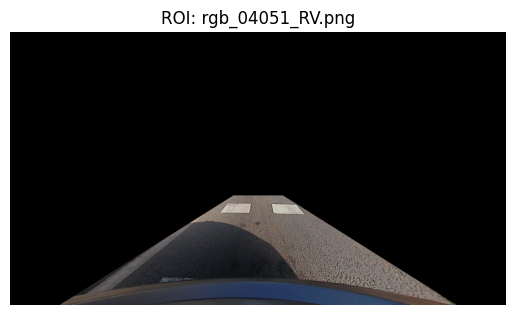

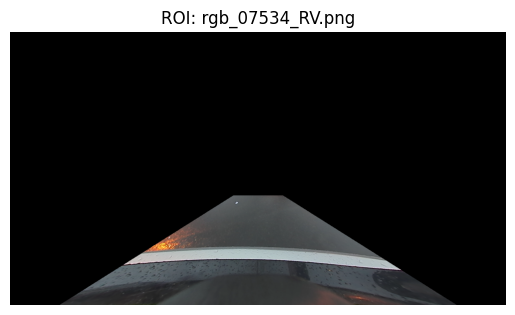

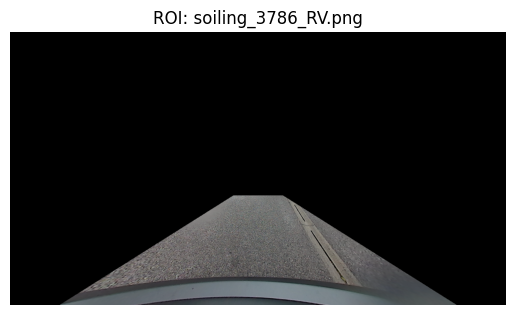

In [10]:
def region_of_interest(image):
    height, width = image.shape[:2]

    # Define polygon 
    polygon = np.array([[
        (int(0.1 * width), height),
        (int(0.45 * width), int(0.6 * height)),
        (int(0.55 * width), int(0.6 * height)),
        (int(0.9 * width), height)
    ]], dtype=np.int32)

    # Create mask
    mask = np.zeros_like(image)

    # Fill polygon with white
    cv2.fillPoly(mask, polygon, (255, 255, 255))

    # Apply mask
    masked_image = cv2.bitwise_and(image, mask)
    return masked_image

rv_undistorted_dir = Path.cwd().parent  / "Notebooks" / "RV_undistorted_results"

test_images = [f for f in os.listdir(rv_undistorted_dir)]
for img_file in test_images:
    img_path = os.path.join(rv_undistorted_dir, img_file)
    image = cv2.imread(img_path)
    roi_image = region_of_interest(image)  # Now passing actual image array
    roi_rgb = cv2.cvtColor(roi_image, cv2.COLOR_BGR2RGB)
    
    plt.imshow(roi_rgb)
    plt.title(f"ROI: {img_file}")
    plt.axis('off')
    plt.show()



🔍 Running detection on: rgb_02727_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_02727_RV.png: 352x640 3 cars, 38.4ms
Speed: 1.9ms preprocess, 38.4ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.57
  - car             conf: 0.49
  - car             conf: 0.29


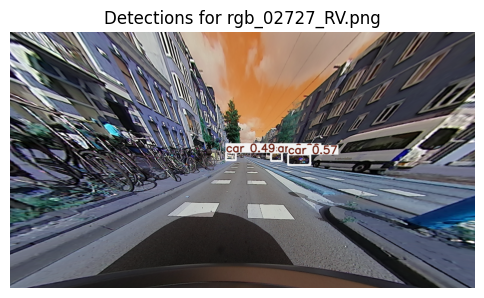


🔍 Running detection on: rgb_02757_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_02757_RV.png: 352x640 5 cars, 31.1ms
Speed: 1.7ms preprocess, 31.1ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.72
  - car             conf: 0.57
  - car             conf: 0.34
  - car             conf: 0.28
  - car             conf: 0.28


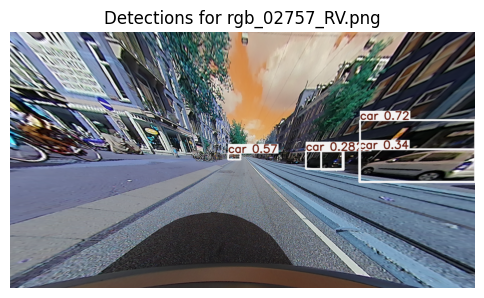


🔍 Running detection on: rgb_04051_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_04051_RV.png: 352x640 1 car, 31.7ms
Speed: 1.2ms preprocess, 31.7ms inference, 0.6ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.29


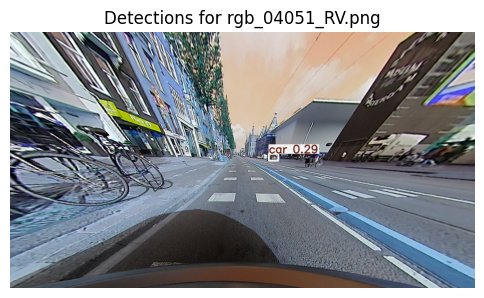


🔍 Running detection on: rgb_07534_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_07534_RV.png: 352x640 3 cars, 33.1ms
Speed: 1.3ms preprocess, 33.1ms inference, 0.6ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.72
  - car             conf: 0.68
  - car             conf: 0.39


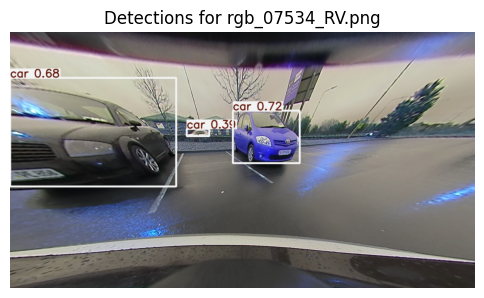


🔍 Running detection on: soiling_3786_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\soiling_3786_RV.png: 352x640 3 cars, 36.6ms
Speed: 2.0ms preprocess, 36.6ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.59
  - car             conf: 0.49
  - car             conf: 0.45


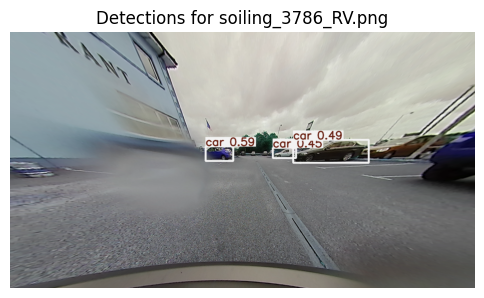

In [5]:
# Folder with undistorted RV PNGs
rv_undistorted_dir = Path.cwd().parent  / "Notebooks" / "RV_undistorted_results"

test_images = [f for f in os.listdir(rv_undistorted_dir)]
for img_file in test_images:
    img_path = os.path.join(rv_undistorted_dir, img_file)
    print(f"\n🔍 Running detection on: {img_file}")
    results = model(img_path, verbose=True)  
    
    # results[0] contains one image's detection info
    for box in results[0].boxes:
        cls_id = int(box.cls)                     # class ID
        conf = float(box.conf)                    # confidence
        cls_name = model.names[cls_id]            # class name (like car, person, etc.)
        print(f"  - {cls_name:<15} conf: {conf:.2f}")

    plotted = results[0].plot()                   # draws boxes + labels on image
    plt.figure(figsize=(6, 4))
    plt.imshow(plotted)
    plt.title(f"Detections for {img_file}")
    plt.axis('off')
    plt.show()
